In [1]:
from utils import load_gaussian
import pandas as pd
from pathlib import Path
from utils.data_loader import load_wine
from utils import load_penguins

import numpy as np
from joblib import Parallel, delayed
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge

from utils import TabularMissingness
from utils import load_iris
from utils import plot_performance_average, plot_experiment_results, plot_imputation_and_alignment

from utils import run_gmm_pipeline

import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import contingency_matrix

from models.gmm import GMMMissing
from utils import TabularMissingness

from sklearn.mixture import GaussianMixture
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score

/home/ilia/PycharmProjects/deep-imputation-techniques/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
missingness = TabularMissingness()

mean_imputer = SimpleImputer(strategy="mean")
knn_imputer = KNNImputer(n_neighbors=5)
iterative_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=20,
    tol=1e-3,
)

missingness_percentages = np.arange(0, 100, 2.5) / 100

In [3]:
X, y = load_gaussian(
    n_samples=1000,
    n_features=2,
    centers=2
)
X = StandardScaler().fit_transform(X)



[]

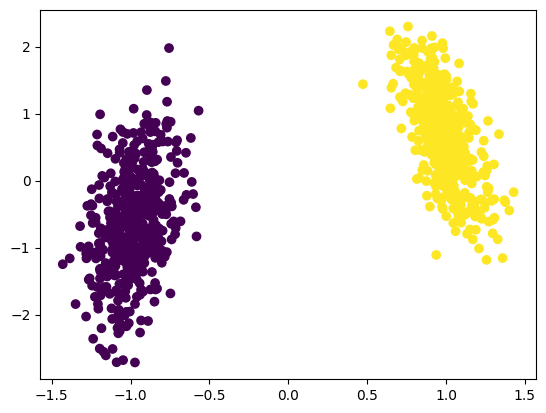

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.plot()

In [5]:
missing_data = missingness.apply_stratified(
    X, y,
    method='mcar',
    frac=0.50,
)


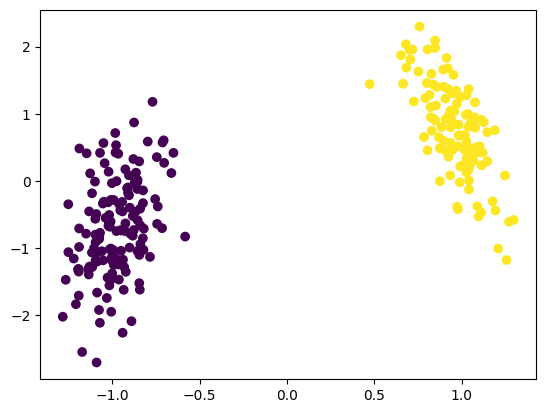

In [6]:
plt.scatter(missing_data[:, 0], missing_data[:, 1], c=y)
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment


def plot_imputation_and_alignment(X, y, n_classes):
    # 1. Setup tools
    tm = TabularMissingness()
    gmm = GMMMissing(n_components=n_classes, random_state=42)

    # 2. Process Data
    missing = tm.apply_stratified(X, y, method="mcar", frac=0.50)
    gmm.fit(missing)

    prediction = gmm.predict(missing)
    imputed = gmm.impute(missing, stochastic=True)

    # 3. Robust Mapping (Fixes the KeyError)
    cm = contingency_matrix(y, prediction)
    row_ind, col_ind = linear_sum_assignment(cm.max() - cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}

    # Use mapping.get(p, p) to fall back to the original index if no map exists
    aligned_predictions = np.array([mapping.get(p, p) for p in prediction])

    # 4. Dimensionality Reduction for Plotting
    is_imputed = np.isnan(missing).any(axis=1)
    use_pca = X.shape[1] > 2

    if use_pca:
        pca = PCA(n_components=2, random_state=42)
        X_plot = pca.fit_transform(X)
        # Note: We fit on X and transform imputed to keep the coordinate system the same
        imputed_plot = pca.transform(imputed)
        x_label, y_label = "PC 1", "PC 2"
    else:
        X_plot = X
        imputed_plot = imputed
        x_label, y_label = "Feature 0", "Feature 1"

    # 5. Visualization
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))

    # Top Left: True Labels
    ax[0, 0].scatter(X_plot[:, 0], X_plot[:, 1], c=y, s=30, alpha=0.7, cmap="viridis")
    ax[0, 0].set_title("Original Data (Ground Truth)")

    # Top Right: Which points were missing
    ax[0, 1].scatter(imputed_plot[:, 0], imputed_plot[:, 1], c=is_imputed, s=30, alpha=0.6, cmap="autumn")
    ax[0, 1].set_title("Imputed Data (Yellow = Filled)")

    # Bottom Left: Predictions mapped to True Label colors
    ax[1, 0].scatter(imputed_plot[:, 0], imputed_plot[:, 1], c=aligned_predictions, s=30, alpha=0.7, cmap="viridis")
    ax[1, 0].set_title("Aligned Predictions")

    # Bottom Right: Red dots indicate errors
    errors = aligned_predictions != y
    ax[1, 1].scatter(imputed_plot[:, 0], imputed_plot[:, 1], c=errors, s=30, alpha=0.7, cmap="coolwarm")
    ax[1, 1].set_title("Clustering Errors (Red = Misclassified)")

    for a in ax.flat:
        a.set_xlabel(x_label)
        a.set_ylabel(y_label)
        a.grid(True, linestyle="--", alpha=0.5)

    fig.tight_layout()
    plt.show()

In [23]:
import numpy as np
from numpy.linalg import inv


class GaussianImputer:
    def __init__(self, stochastic=True):
        self.mu_ = None
        self.sigma_ = None
        self.stochastic = stochastic

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        mask_complete = ~np.isnan(X).any(axis=1)
        X_complete = X[mask_complete]

        if X_complete.shape[0] < 2:
            raise ValueError("Not enough complete rows.")

        self.mu_ = np.mean(X_complete, axis=0)
        self.sigma_ = np.cov(X_complete, rowvar=False)
        return self

    def transform(self, X):
        if self.mu_ is None or self.sigma_ is None:
            raise ValueError("Imputer must be fitted before calling transform().")

        X = np.asarray(X, dtype=float).copy()

        for i in range(X.shape[0]):
            missing = np.isnan(X[i])
            observed = ~missing

            if not np.any(missing):
                continue

            mu_m = self.mu_[missing]
            mu_o = self.mu_[observed]

            # partition covariance matrix
            Sigma_mm = self.sigma_[np.ix_(missing, missing)]
            Sigma_oo = self.sigma_[np.ix_(observed, observed)]
            Sigma_mo = self.sigma_[np.ix_(missing, observed)]
            Sigma_om = self.sigma_[np.ix_(observed, missing)]

            # conditional mean
            cond_mean = mu_m + Sigma_mo @ inv(Sigma_oo) @ (X[i, observed] - mu_o)

            if self.stochastic:
                # conditional covariance
                cond_cov = Sigma_mm - Sigma_mo @ inv(Sigma_oo) @ Sigma_om
                X[i, missing] = np.random.multivariate_normal(cond_mean, cond_cov)
            else:
                X[i, missing] = cond_mean

        return X

    def fit_transform(self, X):
        return self.fit(X).transform(X)


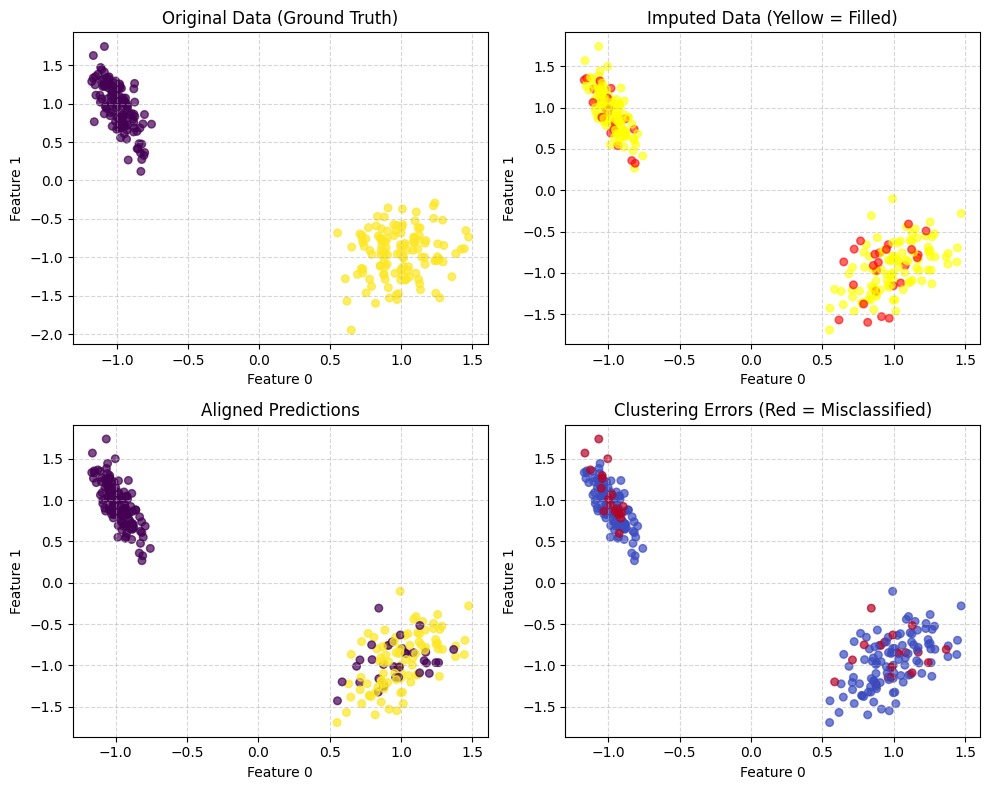

In [24]:
n_classes = 2

X, y = load_gaussian(
    n_samples=250,
    n_features=2,
    centers=n_classes
)
X = StandardScaler().fit_transform(X)

plot_imputation_and_alignment(X, y, n_classes)


In [20]:
missing_data = missingness.apply_stratified(
    X, y,
    method='mcar',
    frac=0.90,
)

# imputed = GaussianImputer().fit_transform(missing_data)
gmm = GMMMissing(n_components=n_classes)
gmm.fit(missing_data)
y_pred = gmm.predict(missing_data)

imputed_scaled = StandardScaler().fit_transform(imputed)
# imputed = knn_imputer.fit_transform(missing_data)
# imputed = X

In [ ]:
plt.scatter(imputed[:, 0], imputed[:, 1], c=y)
plt.show()

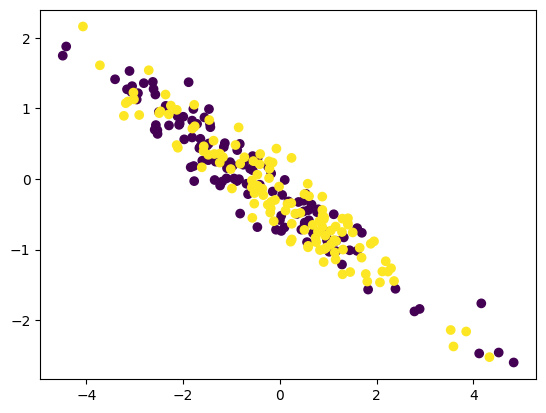

In [21]:
plt.scatter(imputed[:, 0], imputed[:, 1], c=y)
plt.show()